# Comparación de Rendimiento CPU vs GPU (Suma de Vectores)

Nombre: Juan Sebastian Manrique Moreno

Código: 20202107016

### Verificación del entorno CUDA
Antes de comenzar, se verifica que CUDA esté disponible en el entorno actual. Esto es necesario para compilar y ejecutar código en GPU.

In [1]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


### Implementación de la versión en serie (CPU)
Realiza la suma de dos vectores de distintos tamaños (desde $10^1$ hasta $10^{10}$) y mide el tiempo que tarda cada operación.

In [2]:
%%writefile suma_serie.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cmath>

int main() {
    std::cout << "DIM,T_SERIE_MS\n";
    for (int exp = 1; exp <= 8; ++exp) {
        size_t N = pow(10, exp);
        std::vector<float> A(N, 1.0f), B(N, 2.0f), C(N, 0.0f);

        auto start = std::chrono::high_resolution_clock::now();
        for (size_t i = 0; i < N; ++i) {
            C[i] = A[i] + B[i];
        }
        auto end = std::chrono::high_resolution_clock::now();
        std::chrono::duration<double, std::milli> duration = end - start;

        std::cout << N << "," << duration.count() << "\n";
    }
    return 0;
}

Overwriting suma_serie.cpp


### Compilación y ejecución de la versión en CPU
Se compila el archivo `suma_serie.cpp` redirigiendo la salida a un archivo CSV para su análisis posterior.

In [3]:
!g++ suma_serie.cpp -o suma_serie
!./suma_serie > tiempos_serie.csv

### Implementación en CUDA (GPU)
Realiza la misma suma de vectores pero usando la GPU y mide el tiempo de ejecución para vectores desde $10^1$ hasta $10^{10}$.

In [4]:
%%writefile suma_cuda.cu
#include <iostream>
#include <cuda_runtime.h>
#include <cmath>
#include <chrono>

__global__ void sumaCUDA(float *A, float *B, float *C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) C[i] = A[i] + B[i];
}

void inicializar(float *v, float valor, int N) {
    for (int i = 0; i < N; ++i) {
        v[i] = valor;
    }
}

int main() {
    std::cout << "DIM,T_CUDA_MS\n";
    for (int exp = 1; exp <= 8; ++exp) {
        int N = pow(10, exp);
        size_t size = N * sizeof(float);

        float *h_A = (float *)malloc(size);
        float *h_B = (float *)malloc(size);
        float *h_C = (float *)malloc(size);

        if (!h_A || !h_B || !h_C) {
            std::cerr << "Error al asignar memoria en CPU para N = " << N << std::endl;
            continue;
        }

        inicializar(h_A, 1.0f, N);
        inicializar(h_B, 2.0f, N);

        float *d_A, *d_B, *d_C;
        cudaMalloc(&d_A, size);
        cudaMalloc(&d_B, size);
        cudaMalloc(&d_C, size);

        cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
        cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

        int threadsPerBlock = 256;
        int blocksPerGrid = (N + threadsPerBlock - 1) / threadsPerBlock;

        cudaDeviceSynchronize();
        auto start = std::chrono::high_resolution_clock::now();

        sumaCUDA<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C, N);

        cudaDeviceSynchronize();
        auto end = std::chrono::high_resolution_clock::now();
        std::chrono::duration<double, std::milli> duration = end - start;

        std::cout << N << "," << duration.count() << "\n";

        cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);

        cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
        free(h_A); free(h_B); free(h_C);
    }
    return 0;
}

Overwriting suma_cuda.cu


### Compilación y ejecución de la versión CUDA
Se compila el archivo CUDA usando `nvcc` redirigiendo su salida a un archivo CSV.

In [5]:
!nvcc suma_cuda.cu -o suma_cuda
!./suma_cuda > tiempos_cuda.csv

### Lectura de resultados y combinación en un solo DataFrame
Se cargan los archivos `tiempos_serie.csv` y `tiempos_cuda.csv`, combinándolos para visualización conjunta.

In [6]:
import pandas as pd

# Leer CSVs
serie = pd.read_csv("tiempos_serie.csv")
cuda = pd.read_csv("tiempos_cuda.csv")

# Unir por columna DIM
df = pd.merge(serie, cuda, on="DIM")
df.columns = ["Tamaño", "CPU (ms)", "GPU (ms)"]
df

,Tamaño,CPU (ms),GPU (ms)
0,10,0.000360,0.005737
1,100,0.001794,0.000266
2,1000,0.016133,0.000170
3,10000,0.188248,0.000167
4,100000,1.688680,0.000306
5,1000000,38.967800,0.001648
6,10000000,348.220000,0.001766
7,100000000,950.175000,0.002391


### Gráfica comparativa CPU vs GPU
Se crean dos gráficas, una con los datos procesados y otra con los datos de forma $\log$-$\log$ para comparar visualmente el rendimiento entre CPU y GPU a medida que crece el tamaño del vector.

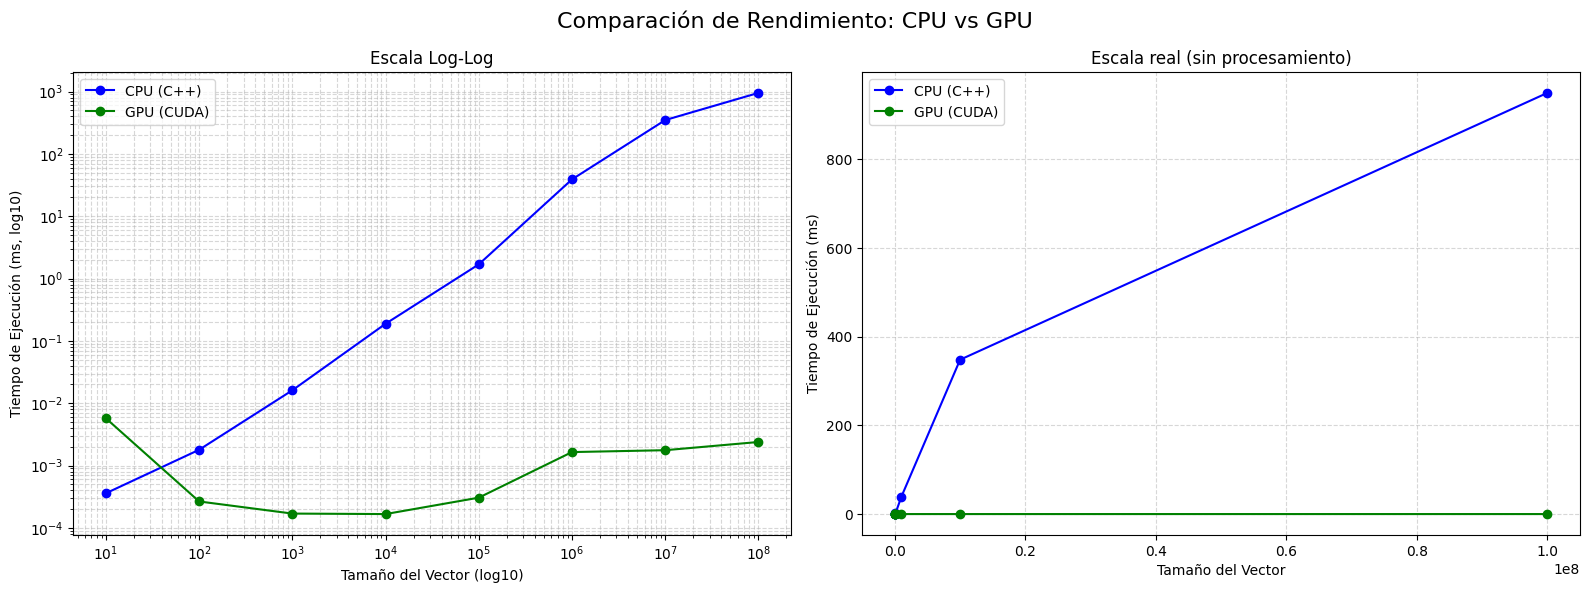

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Log-log
axs[0].plot(df["Tamaño"], df["CPU (ms)"], marker='o', label="CPU (C++)", color='blue')
axs[0].plot(df["Tamaño"], df["GPU (ms)"], marker='o', label="GPU (CUDA)", color='green')
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].set_xlabel("Tamaño del Vector (log10)")
axs[0].set_ylabel("Tiempo de Ejecución (ms, log10)")
axs[0].set_title("Escala Log-Log")
axs[0].grid(True, which="both", linestyle="--", alpha=0.5)
axs[0].legend()

# Subplot 2: sin procesamiento
axs[1].plot(df["Tamaño"], df["CPU (ms)"], marker='o', label="CPU (C++)", color='blue')
axs[1].plot(df["Tamaño"], df["GPU (ms)"], marker='o', label="GPU (CUDA)", color='green')
axs[1].set_xlabel("Tamaño del Vector")
axs[1].set_ylabel("Tiempo de Ejecución (ms)")
axs[1].set_title("Escala real (sin procesamiento)")
axs[1].grid(True, linestyle="--", alpha=0.5)
axs[1].legend()

plt.suptitle("Comparación de Rendimiento: CPU vs GPU", fontsize=16)
plt.tight_layout()
plt.show()